In [14]:
import numpy as np
import nidaqmx
from nidaqmx.constants import (
    TerminalConfiguration, 
    AcquisitionType,
    Edge,
    TaskMode
)
import qcodes as qc
from qcodes import Station, Parameter
from qcodes.dataset import (
    initialise_database,
    load_or_create_experiment,
    Measurement,
)
import matplotlib.pyplot as plt

In [ ]:
# ─────────────────────────────────────────────
# 1. QCoDeS STATION SETUP
# ─────────────────────────────────────────────
station = Station()

In [20]:
# ─────────────────────────────────────────────
# 2. ACQUISITION PARAMETERS
# ─────────────────────────────────────────────
DEVICE          = "Dev1"
SIGNAL_CHANNEL  = f"{DEVICE}/ai14"   # circuit signal
TRIGGER_PIN     = f"/{DEVICE}/PFI8"  # cable from M3102A Trig Out

SAMPLE_RATE = 500_000       # Hz — adjust to your IF frequency
NUM_SAMPLES = 50_000
V_MIN, V_MAX = -1.5, 1.5   # expected voltage range at DAQ input

In [21]:
# ─────────────────────────────────────────────
# 3. WRAP DAQ ACQUISITION AS A QCoDeS PARAMETER
# ─────────────────────────────────────────────
class TriggeredCircuitTrace(Parameter):
    """Waits for M3102A trigger on PFI0, then acquires."""

    def get_raw(self):
        with nidaqmx.Task() as task:
            task.ai_channels.add_ai_voltage_chan(
                SIGNAL_CHANNEL,
                terminal_config=TerminalConfiguration.RSE,
                min_val=V_MIN,
                max_val=V_MAX,
            )
            task.timing.cfg_samp_clk_timing(
                rate=SAMPLE_RATE,
                sample_mode=AcquisitionType.FINITE,
                samps_per_chan=NUM_SAMPLES,
            )
            # Wait for rising edge on PFI0 before starting
            task.triggers.start_trigger.cfg_dig_edge_start_trig(
                trigger_source=TRIGGER_PIN,
                trigger_edge=Edge.RISING,
            )
            task.start()
            print("Waiting for trigger from M3102A...")
            # Timeout: adjust to your expected wait time (seconds)
            data = task.read(
                number_of_samples_per_channel=NUM_SAMPLES,
                timeout=60.0,
            )
        return np.array(data)


circuit_trace = TriggeredCircuitTrace(
    name="circuit_trace", 
    label="Circuit signal", 
    unit="V"
)

In [22]:
# ─────────────────────────────────────────────
# 4. DATABASE & EXPERIMENT
# ─────────────────────────────────────────────
initialise_database()   # creates qcodes_experiments.db if not present
exp = load_or_create_experiment(
    experiment_name="signal_acquisition",
    sample_name="test",
)

In [29]:
# ─────────────────────────────────────────────
# 5. RUN A MEASUREMENT
# ─────────────────────────────────────────────
meas = Measurement(exp)
meas.register_custom_parameter("time",  label="Time",    unit="s")
meas.register_custom_parameter("voltage", label="Voltage", unit="V",
                                setpoints=["time"])

with meas.run() as datasaver:
    signal = circuit_trace.get()
    time   = np.arange(NUM_SAMPLES) / SAMPLE_RATE

    datasaver.add_result(
        ("time",    time),
        ("voltage", signal),
    )
    run_id = datasaver.run_id

print(f"Data saved — run ID: {run_id}")

Starting experimental run with id: 83. 
Waiting for trigger from M3102A...


An exception occurred in measurement with guid: 1d416a92-0000-0000-0000-019e414e43e7;
Traceback:
Traceback (most recent call last):
  File "C:\Users\quantum\AppData\Local\Temp\ipykernel_16820\2007038217.py", line 10, in <module>
    signal = circuit_trace.get()
             ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\quantum\AppData\Local\Programs\Python\Python311\Lib\site-packages\qcodes\parameters\parameter_base.py", line 909, in get_wrapper
    raise e
  File "c:\Users\quantum\AppData\Local\Programs\Python\Python311\Lib\site-packages\qcodes\parameters\parameter_base.py", line 896, in get_wrapper
    raw_value = get_function(*args, **kwargs)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\quantum\AppData\Local\Temp\ipykernel_16820\1835506268.py", line 28, in get_raw
    data = task.read(
           ^^^^^^^^^^
  File "c:\Users\quantum\AppData\Local\Programs\Python\Python311\Lib\site-packages\nidaqmx\task\_task.py", line 624, in read
    _, samples_read = self._interpreter.read

DaqReadError: ('Some or all of the samples requested have not yet been acquired.\nTo wait for the samples to become available use a longer read timeout or read later in your program. To make the samples available sooner, increase the sample rate. If your task uses a start trigger,  make sure that your start trigger is configured correctly. It is also possible that you configured the task for external timing, and no clock was supplied. If this is the case, supply an external clock.\nProperty: DAQmx_Read_RelativeTo\nCorresponding Value: DAQmx_Val_CurrReadPos\nProperty: DAQmx_Read_Offset\nCorresponding Value: 0\n\nTask Name: _unnamedTask<A>\n\nStatus Code: -200284', 'getting circuit_trace')

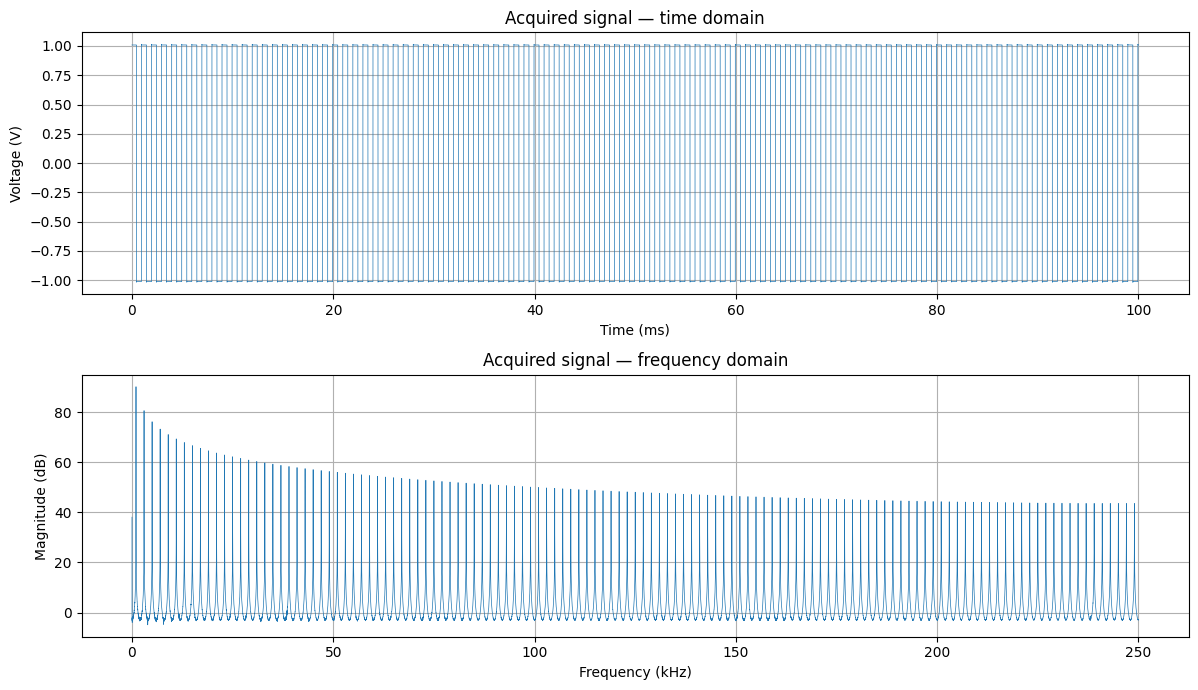

In [7]:
# ─────────────────────────────────────────────
# 6. PLOT
# ─────────────────────────────────────────────
time_ms = time * 1e3

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

# Time domain
ax1.plot(time_ms, signal, linewidth=0.5)
ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("Voltage (V)")
ax1.set_title("Acquired signal — time domain")
ax1.grid(True)

# Frequency domain
N  = len(signal)
yf = np.abs(np.fft.fft(signal))[:N//2]
xf = np.fft.fftfreq(N, 1 / SAMPLE_RATE)[:N//2]
ax2.plot(xf / 1e3, 20 * np.log10(yf + 1e-12), linewidth=0.5)
ax2.set_xlabel("Frequency (kHz)")
ax2.set_ylabel("Magnitude (dB)")
ax2.set_title("Acquired signal — frequency domain")
ax2.grid(True)

plt.tight_layout()
plt.show()